In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_import import load_data
from src.preprocessing import convert_categorical_dtype

df = load_data("../data/alzheimers_disease_data.csv")

df_cat = convert_categorical_dtype(df.copy())

df.head()

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
0,4751,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,...,0,0,1.725883,0,0,0,1,0,0,XXXConfid
1,4752,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,...,0,0,2.592424,0,0,0,0,1,0,XXXConfid
2,4753,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,...,0,0,7.119548,0,1,0,1,0,0,XXXConfid
3,4754,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,...,0,1,6.481226,0,0,0,0,0,0,XXXConfid
4,4755,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,...,0,0,0.014691,0,0,1,1,0,0,XXXConfid


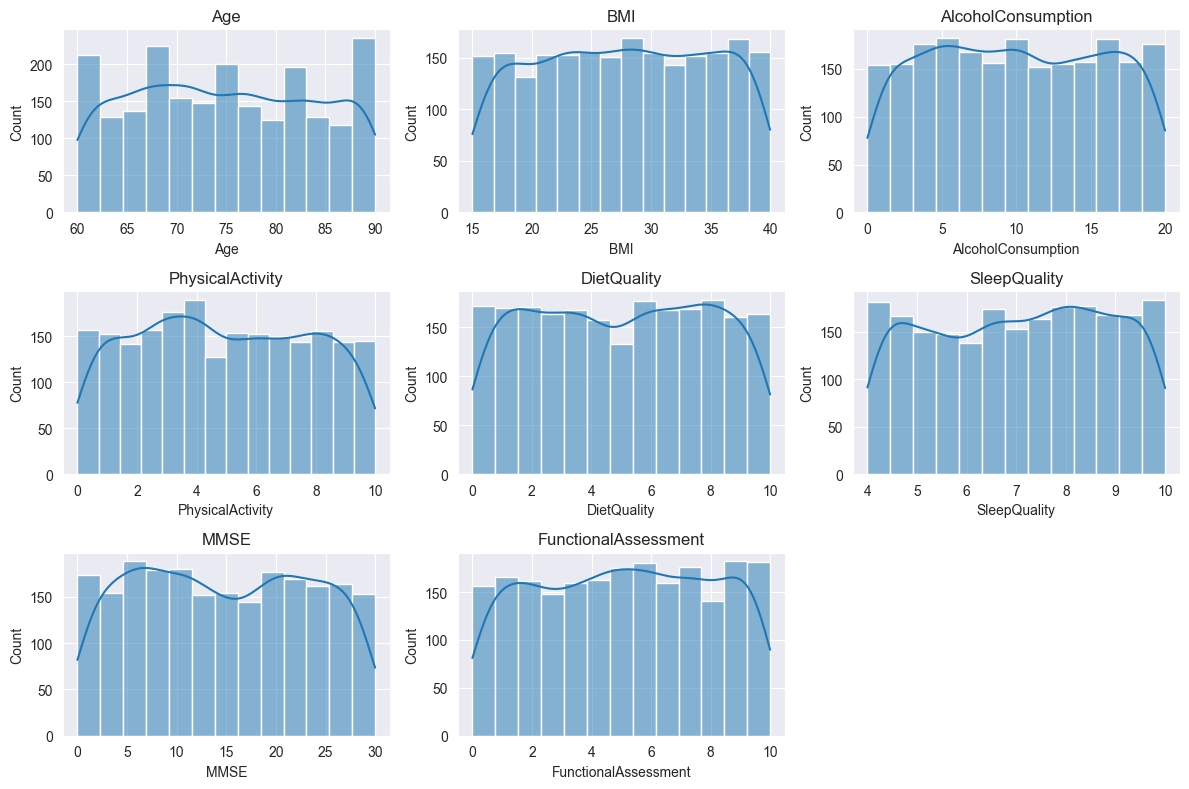

In [13]:
# Podstawowe statystyki dla cech numerycznych
df.describe().T

num_cols = [
    'Age','BMI','AlcoholConsumption','PhysicalActivity',
    'DietQuality','SleepQuality','MMSE','FunctionalAssessment'
]

plt.figure(figsize=(12, 8))
for i, col in enumerate(num_cols, 1):
    plt.subplot(3,3,i)
    sns.histplot(df[col], kde=True)
    plt.title(col)
plt.tight_layout()

Text(0.5, 1.0, 'Correlation matrix')

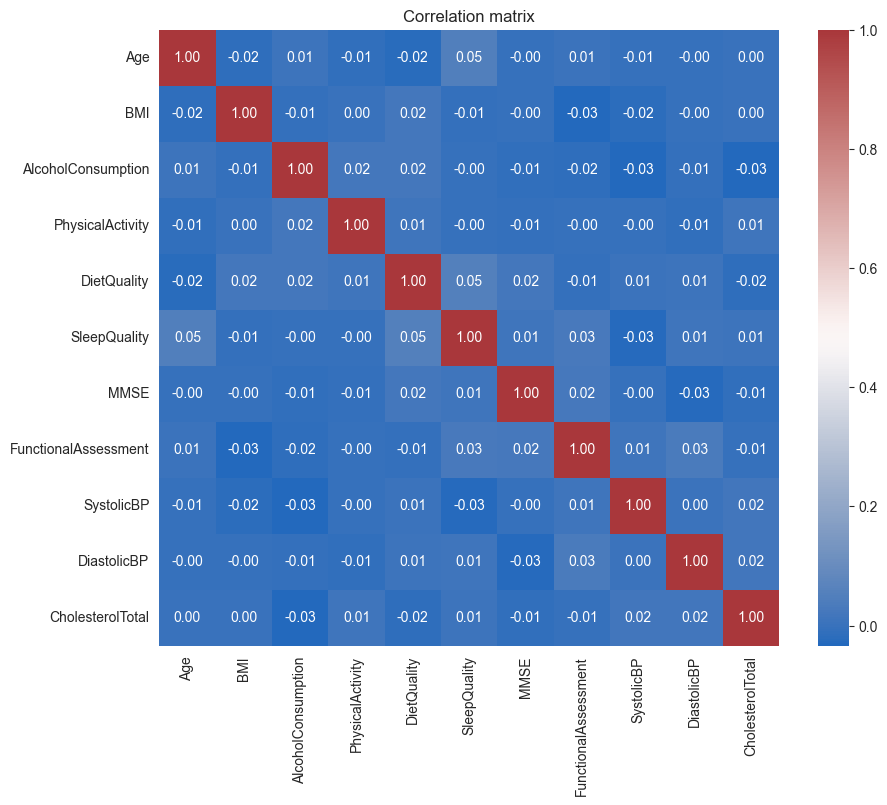

In [14]:
# Macierz korelacji tylko cech numerycznych
corr = df[num_cols + ['SystolicBP','DiastolicBP','CholesterolTotal']].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag")
plt.title("Correlation matrix")

Text(0.5, 1.0, 'MMSE by Diagnosis (0=healthy, 1=AD)')

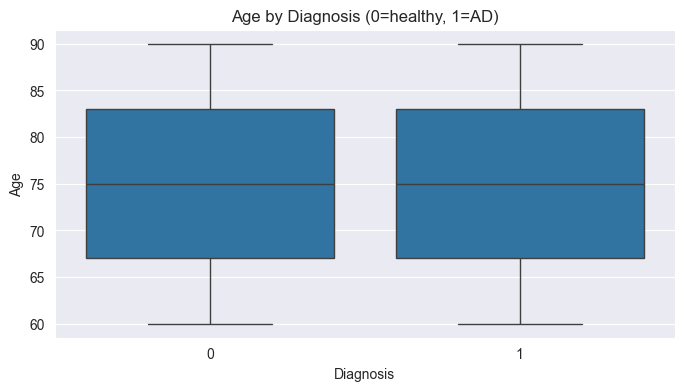

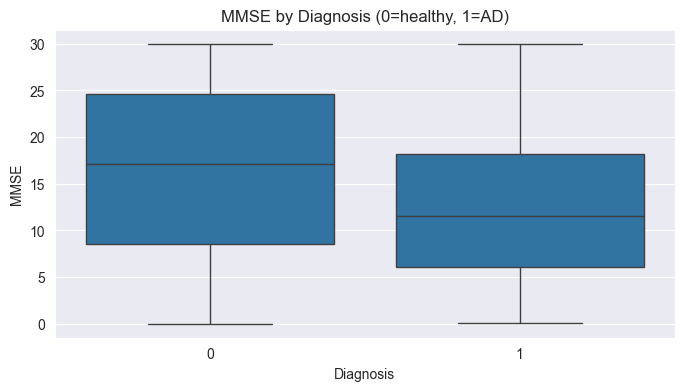

In [15]:
# Boxplot porównujący Age i MMSE między grupami
plt.figure(figsize=(8,4))
sns.boxplot(x=df['Diagnosis'], y=df['Age'])
plt.title("Age by Diagnosis (0=healthy, 1=AD)")

plt.figure(figsize=(8,4))
sns.boxplot(x=df['Diagnosis'], y=df['MMSE'])
plt.title("MMSE by Diagnosis (0=healthy, 1=AD)")

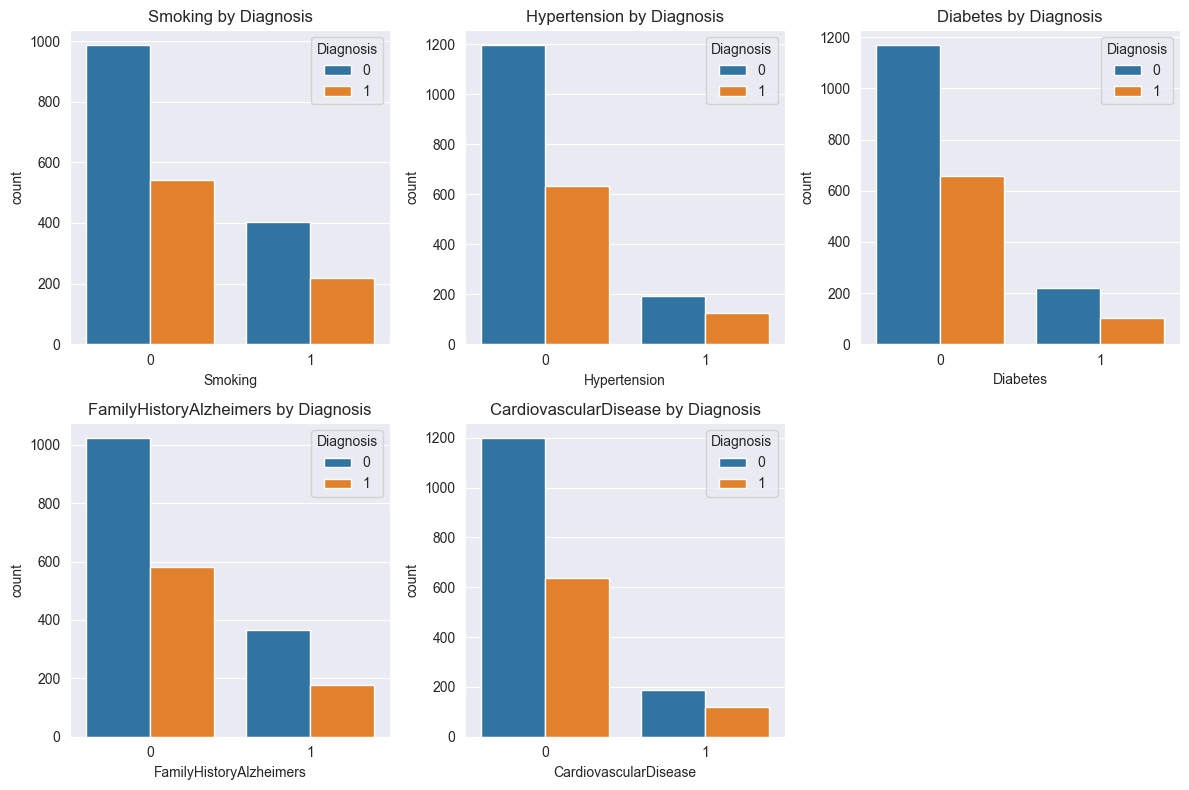

In [16]:
# Barplots dla zmiennych binarnych
binary_cols = [
    'Smoking', 'Hypertension', 'Diabetes',
    'FamilyHistoryAlzheimers', 'CardiovascularDisease'
]

plt.figure(figsize=(12, 8))
for i, col in enumerate(binary_cols, 1):
    plt.subplot(2, 3, i)
    sns.countplot(x=col, hue=df['Diagnosis'], data=df)
    plt.title(f"{col} by Diagnosis")
    plt.legend(title='Diagnosis', loc='upper right')
plt.tight_layout()

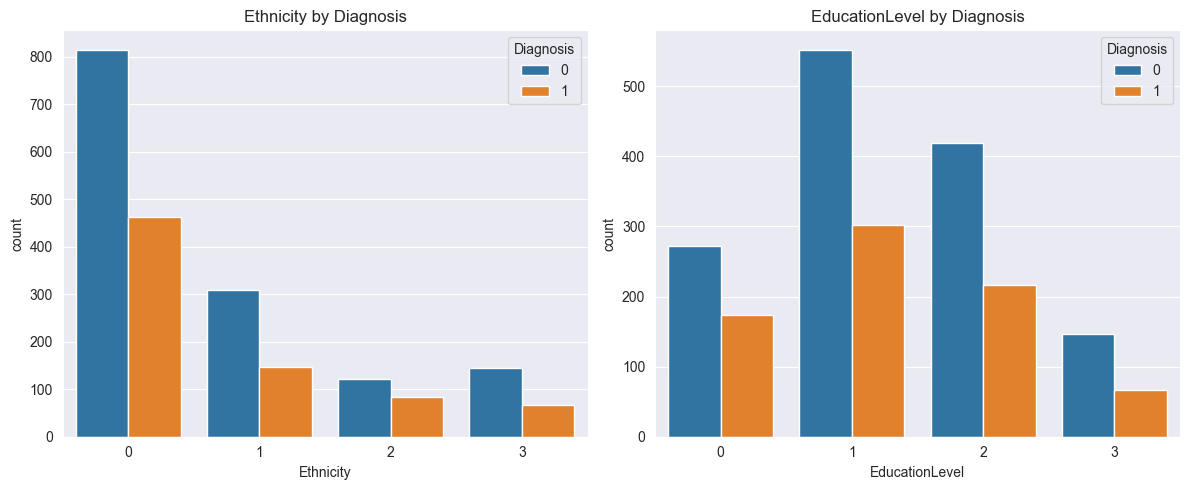

In [17]:
# Countplot dla zmiennych kategorycznych
plt.figure(figsize=(12, 5))
plt.subplot(1,2,1)
sns.countplot(x='Ethnicity', hue=df['Diagnosis'], data=df)
plt.title("Ethnicity by Diagnosis")

plt.subplot(1,2,2)
sns.countplot(x='EducationLevel', hue=df['Diagnosis'], data=df)
plt.title("EducationLevel by Diagnosis")
plt.tight_layout()

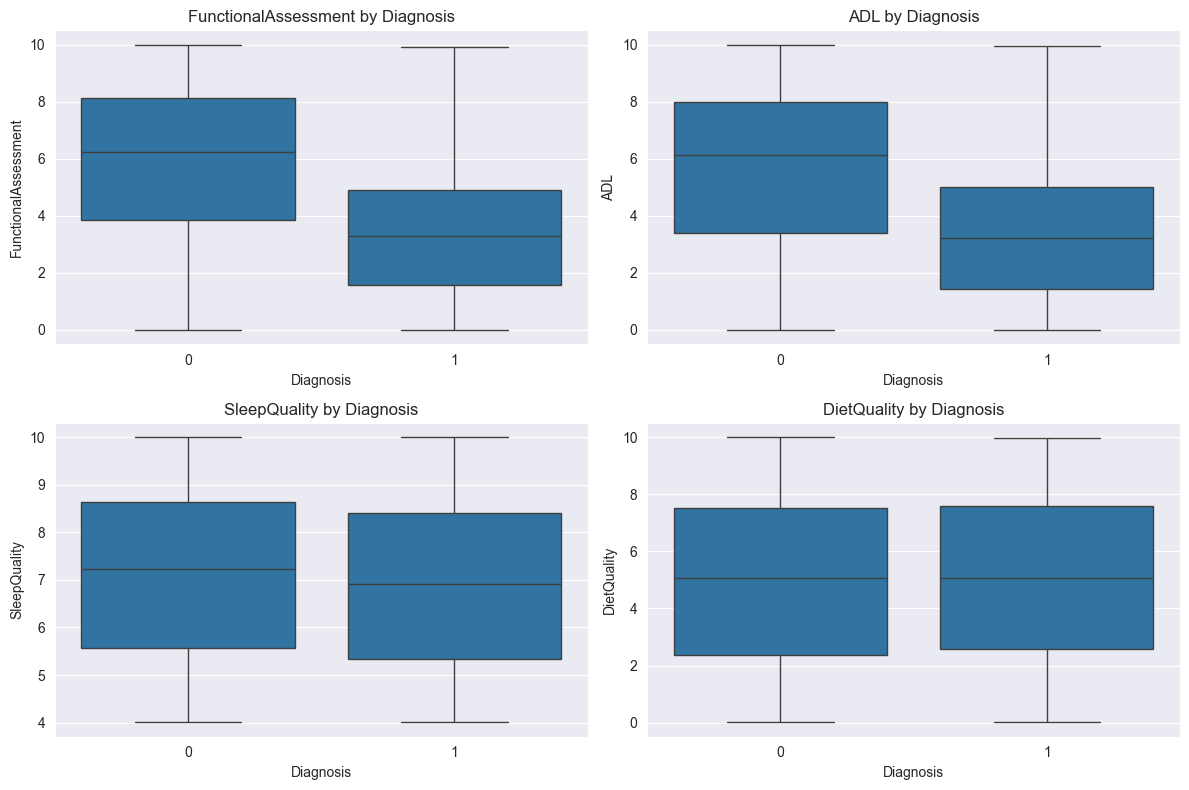

In [18]:
# Boxplots dla dodatkowych cech numerycznych
other_num = ['FunctionalAssessment', 'ADL', 'SleepQuality', 'DietQuality']
plt.figure(figsize=(12, 8))
for i, col in enumerate(other_num, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x=df['Diagnosis'], y=df[col], data=df)
    plt.title(f"{col} by Diagnosis")
plt.tight_layout()